#  Project:Job Salary Prediction

## 1. Problem Understanding

### Objective
Predict an individual's salary based on job-related and personal attributes (experience, education, job role, industry, location, skills, certifications, company size, remote work, etc.).

### Business Value
| Stakeholder | Benefit |
|---|---|
| Companies | Helps in offering competitive and fair salaries |
| HR Teams | Enables data-driven hiring and compensation decisions |
| Job Seekers | Provides insights into market salary expectations |

### ML Formulation
- **Type:** Supervised Regression  
- **Input (X):** Experience, education, job title, industry, location, skills, certifications, company size, remote work  
- **Target (y):** Salary (continuous variable)

### Success Metrics
| Metric | Description |
|---|---|
| **R² Score** | Variance explained (higher = better) |
| **MAE** | Mean absolute error in actual salary units |
| **RMSE** | Penalises large errors more than MAE |


### Objective Summary

The goal is to build a robust and accurate regression model that can generalize well to unseen data and provide meaningful insights into the key factors influencing salary.


## 2. Data Understanding & EDA

In [1]:
#  Basic Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#  Warnings
import warnings
warnings.filterwarnings("ignore")

# Scikit-learn - Preprocessing & Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#  Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
#  Evaluation Metrics
from sklearn.metrics import r2_score, mean_squared_error

#  Model Saving
import joblib


In [2]:
df = pd.read_csv("job_salary_prediction_dataset .csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (250000, 10)


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


The dataset contains 250,000 records and 10 features, providing a large and diverse sample for building a robust salary prediction model.
It includes a mix of categorical and numerical variables, covering job role, experience, skills, and company-related attributes.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
job_title,250000,12,Backend Developer,21125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experience_years,250000.0,NaN,NaN,NaN,10.005408,6.060602,0.0,5.0,10.0,15.0,20.0
education_level,250000,5,Master,50352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
skills_count,250000.0,NaN,NaN,NaN,9.997812,5.479288,1.0,5.0,10.0,15.0,19.0
industry,250000,10,Finance,25393,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_size,250000,5,Large,50254,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,250000,10,Australia,25258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
remote_work,250000,3,No,83621,NaN,NaN,NaN,NaN,NaN,NaN,NaN
certifications,250000.0,NaN,NaN,NaN,2.491928,1.706475,0.0,1.0,2.0,4.0,5.0
salary,250000.0,NaN,NaN,NaN,145718.080524,37407.952729,31867.0,119358.0,143453.0,169492.0,333046.0


The dataset shows balanced categorical distributions (e.g., job roles = 12, locations = 10), with no high-cardinality issues, making encoding straightforward.

Salary ranges from ~31K to ~333K with a mean ~145K, indicating a wide but realistic spread, while experience (0–20 years) and skills (1–19) are evenly distributed.

In [5]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nDuplicates: {df.duplicated().sum()}")


Missing values:
job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

Duplicates: 0


The dataset contains no missing values and no duplicate records, indicating high data quality and reliability.Since the data is already clean, no imputation or duplicate handling is required, allowing direct progression to modeling.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

## 1. Univariant
### Salary Distribution

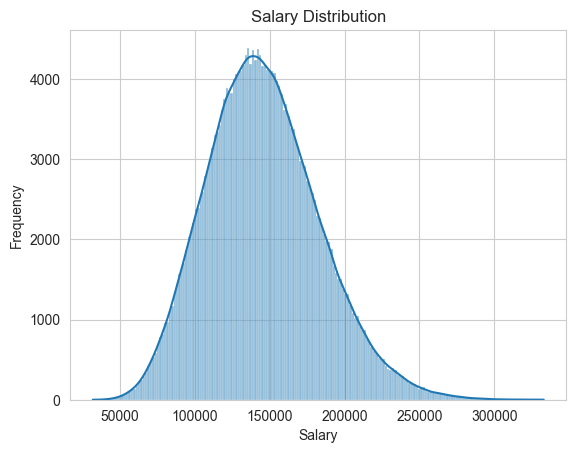

In [7]:
plt.figure()
sns.histplot(df['salary'], kde=True)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

The salary distribution is approximately unimodal with a slight positive (right) skew. Most values are concentrated between 120K and 170K, with a longer tail extending toward higher salary ranges (above 250K), indicating the presence of high-income observations.

### Experience Distribution

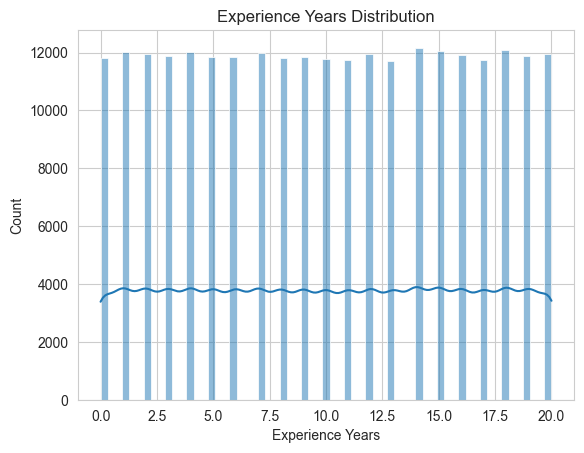

In [8]:
plt.figure()
sns.histplot(df['experience_years'], kde=True)
plt.title("Experience Years Distribution")
plt.xlabel("Experience Years")
plt.ylabel("Count")
plt.show()

Experience years appear to be uniformly distributed across the range of 0–20 years, with roughly equal representation at each level. This indicates no concentration in specific experience ranges, although such a uniform pattern may not reflect real-world distributions where mid-level experience is more common.

## 2.Bivariate Plot  
### Experience vs Salary

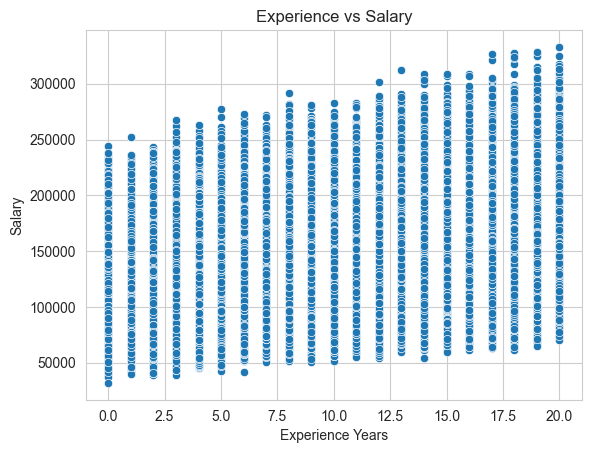

In [9]:
plt.figure()
sns.scatterplot(x=df['experience_years'], y=df['salary'])
plt.title("Experience vs Salary")
plt.xlabel("Experience Years")
plt.ylabel("Salary")
plt.show()

Salary shows a clear positive correlation with experience, increasing steadily as years of experience grow.
However, there is noticeable spread at each level, indicating other factors (skills, role, etc.) also influence salary.

### Education Level vs Salary

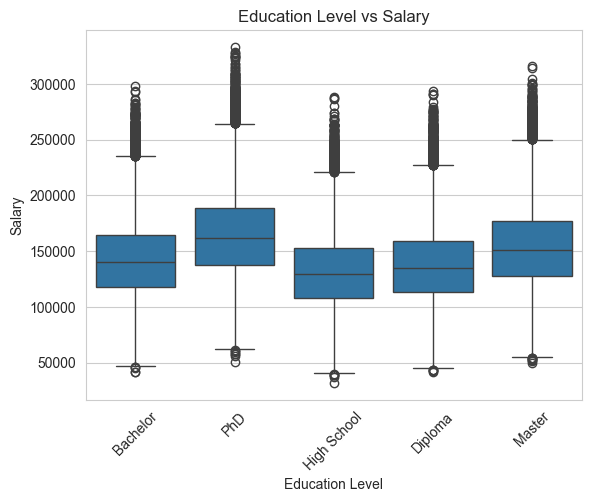

In [10]:
plt.figure()
sns.boxplot(x=df['education_level'], y=df['salary'])
plt.title("Education Level vs Salary")
plt.xlabel("Education Level")
plt.ylabel("Salary")
plt.xticks(rotation=45)
plt.show()

The scatter plot shows a clear positive relationship between experience and salary, where higher experience levels generally correspond to higher salary ranges. However, there is significant vertical spread at each experience level, indicating that factors beyond experience (such as job role, industry, or skills) also influence salary.

## 3.Multivariate Plot 
### Experience vs Salary (Job Title as Hue)

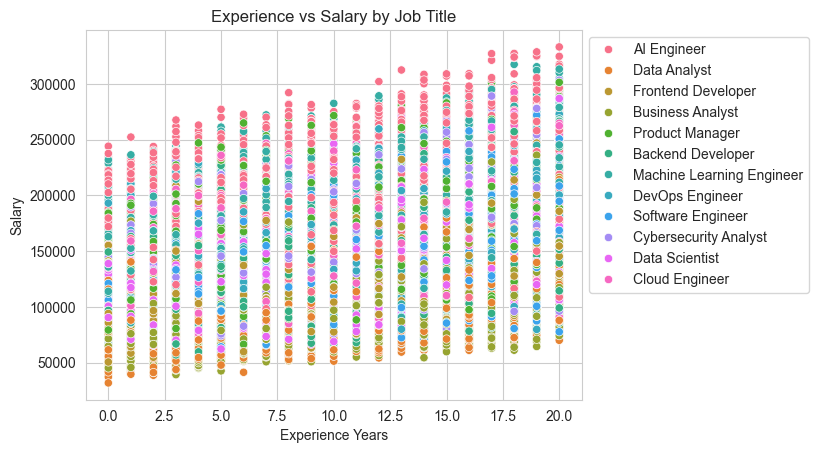

In [11]:
plt.figure()
sns.scatterplot(x=df['experience_years'], y=df['salary'], hue=df['job_title'])
plt.title("Experience vs Salary by Job Title")
plt.xlabel("Experience Years")
plt.ylabel("Salary")
plt.legend(bbox_to_anchor=(1,1))
plt.show()

The relationship between experience and salary remains positively correlated across all job roles. However, different job titles exhibit distinct salary ranges, with some roles (such as AI Engineer and Machine Learning Engineer) consistently earning higher salaries compared to others like Data Analyst or Business Analyst. This indicates that both experience and job role significantly influence salary.

### Correlation Heatmap

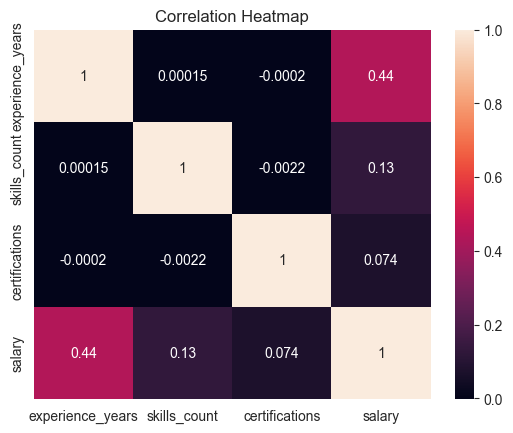

In [12]:
plt.figure()
corr = df[['experience_years', 'skills_count', 'certifications', 'salary']].corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows that experience_years has a moderate positive correlation (0.44) with salary, making it the most influential numeric feature. In contrast, skills_count (0.13) and certifications (0.074) have very weak correlations with salary. Additionally, there is almost no correlation among the independent features themselves, indicating low multicollinearity.

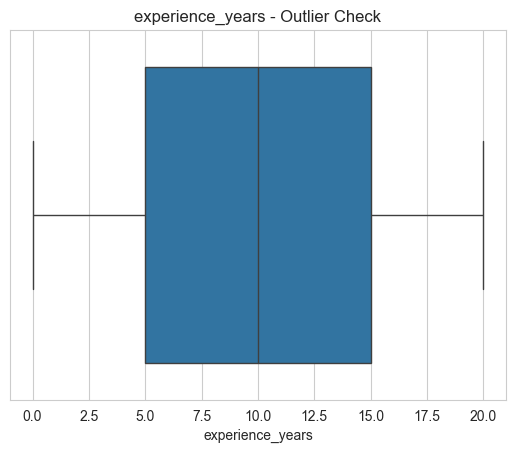

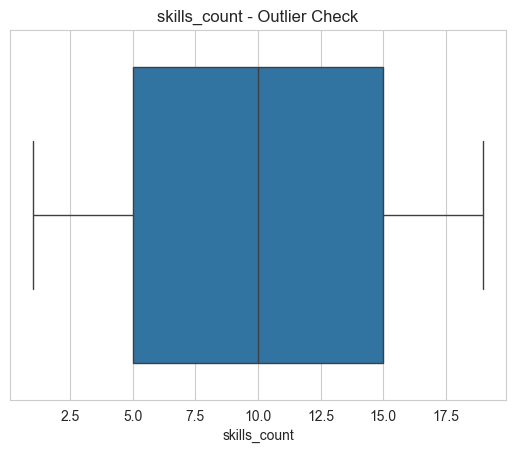

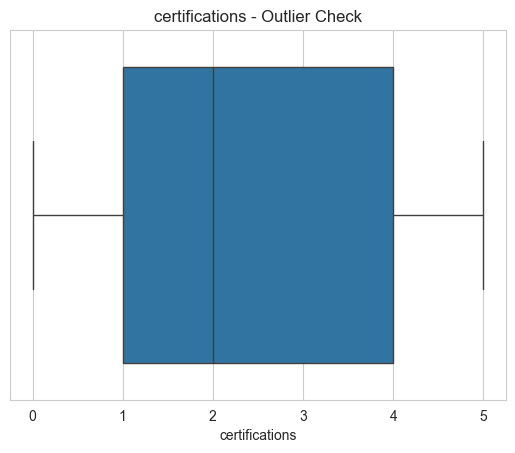

In [13]:
num_cols = ['experience_years', 'skills_count', 'certifications']
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"{col} - Outlier Check")
    plt.show()

Outlier analysis was performed on the independent numerical features (experience_years, skills_count, and certifications) using the IQR method and boxplots. The analysis showed that these features do not contain significant outliers, as their values fall within expected ranges and distributions. Therefore, no outlier treatment was required for the input variables.

## 3. Feature Engineering

To enhance model performance and capture deeper relationships within the data, the following features were created:

**Created Features:**

`experience_level:` Experience years were grouped into categorical levels (Fresher, Mid, Senior, Expert) to capture non-linear career progression patterns.

`skill_density:` A ratio of skills to experience was created to represent how efficiently an individual has acquired skills over time.

`strength_score:` A composite feature was designed by combining experience, skills, and certifications using weighted aggregation. This provides a balanced representation of an individual’s overall professional strength while avoiding extreme value scaling.


In [14]:
def experience_level(x):
    if x <= 2:
        return 'Fresher'
    elif x <= 7:
        return 'Mid'
    elif x <= 15:
        return 'Senior'
    else:
        return 'Expert'
df['experience_level'] = df['experience_years'].apply(experience_level)

In [15]:
df['skill_density'] = df['skills_count'] / (df['experience_years'] + 1)

In [16]:
df['strength_score'] = (
    df['experience_years']  +
    df['skills_count']  +
    df['certifications'] 
)

In [17]:
corr = df.corr(numeric_only=True)
print(corr)

                  experience_years  skills_count  certifications    salary  \
experience_years          1.000000      0.000149       -0.000198  0.437627   
skills_count              0.000149      1.000000       -0.002230  0.127300   
certifications           -0.000198     -0.002230        1.000000  0.073819   
salary                    0.437627      0.127300        0.073819  1.000000   
skill_density            -0.572073      0.362440       -0.003405 -0.204272   
strength_score            0.726362      0.656292        0.202897  0.416537   

                  skill_density  strength_score  
experience_years      -0.572073        0.726362  
skills_count           0.362440        0.656292  
certifications        -0.003405        0.202897  
salary                -0.204272        0.416537  
skill_density          1.000000       -0.178203  
strength_score        -0.178203        1.000000  


Experience_years shows the strongest positive correlation with salary (0.44), making it the most influential numerical feature. The engineered feature strength_score also shows a moderate correlation (0.41), but it is highly correlated with experience and skills, indicating redundancy rather than a completely new signal. Skills_count and certifications have weak individual correlations with salary, suggesting that salary is influenced by multiple factors and interactions rather than any single variable alone.

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   job_title         250000 non-null  object 
 1   experience_years  250000 non-null  int64  
 2   education_level   250000 non-null  object 
 3   skills_count      250000 non-null  int64  
 4   industry          250000 non-null  object 
 5   company_size      250000 non-null  object 
 6   location          250000 non-null  object 
 7   remote_work       250000 non-null  object 
 8   certifications    250000 non-null  int64  
 9   salary            250000 non-null  int64  
 10  experience_level  250000 non-null  object 
 11  skill_density     250000 non-null  float64
 12  strength_score    250000 non-null  int64  
dtypes: float64(1), int64(5), object(7)
memory usage: 24.8+ MB


In [19]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
experience_level    0
skill_density       0
strength_score      0
dtype: int64

In [20]:
df.duplicated().sum()

0

## 3. Data Preprocessing

The dataset is divided into features (X) and target variable (y), where salary is the dependent variable to be predicted.
This separation ensures a clear distinction between input variables and output, which is essential for building a supervised learning model.

In [20]:
X = df.drop('salary', axis=1)
y = df['salary']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [23]:
cat_cols = [
    'job_title', 'education_level', 'industry',
    'company_size', 'location', 'remote_work',
    'experience_level'
]
num_cols = [
    'experience_years', 'skills_count', 'certifications',
    'skill_density', 'strength_score'
]

In [26]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore",sparse_output=False), cat_cols)
])

In [27]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

Numerical features are scaled using StandardScaler, and categorical features are encoded using OneHotEncoder, ensuring all variables are in a model-compatible format.
A ColumnTransformer pipeline is used to apply transformations consistently, preventing data leakage by fitting only on training data and transforming test data separately.

## 4. Model Selection

Linear Regression:
A simple baseline model that assumes a linear relationship between features and the target variable (salary).

Ridge Regression:
A linear model with L2 regularization that reduces overfitting by shrinking coefficients, especially useful when features are correlated.

Lasso Regression:
A linear model with L1 regularization that performs feature selection by shrinking some coefficients to zero.

Random Forest Regressor:
An ensemble of decision trees that captures complex non-linear relationships and interactions between features.

Gradient Boosting Regressor:
A sequential ensemble model that improves performance by correcting the errors of previous models.

XGBoost Regressor:
An optimized gradient boosting algorithm that provides high performance and efficiently handles complex patterns in the data.

In [28]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoost": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42)}
results = []
for name, model in models.items():
    model.fit(X_train_processed, y_train)
    preds = model.predict(X_test_processed)   
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds)) 
    results.append((name, r2, rmse))
results = sorted(results, key=lambda x: x[1], reverse=True)
for r in results:
    print(r)

('XGBoost', 0.9807632586014126, 5170.729861798812)
('RandomForest', 0.9725567400901374, 6175.952472537861)
('Lasso', 0.9634674091957238, 7125.680276944288)
('Ridge', 0.9634658198656818, 7125.835274636955)
('Linear', 0.9634642857140516, 7125.984887916898)
('GradientBoost', 0.9544871640114744, 7953.4040268233)


Among all models, XGBoost achieved the highest performance with an R² score of 0.98 and the lowest RMSE, making it the best-performing model. Tree-based ensemble methods outperformed linear models, indicating the presence of non-linear relationships in the data. Linear models still performed well, suggesting that the dataset also contains strong linear patterns.

# 6. Model Training & Tuning

In [29]:
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42))
])
param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [4, 6, 8],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}
random_search = RandomizedSearchCV(
    xgb_pipe,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 6, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}


RandomizedSearchCV identified a well-performing set of hyperparameters for XGBoost. The selected configuration, including 200 trees, max depth of 6, and learning rate of 0.1, allows the model to capture complex patterns while maintaining generalization. The use of subsample (0.8) and colsample_bytree (0.8) helps reduce overfitting by introducing randomness during training.

# 7. Model Evaluation

In [30]:
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
print("\n=== FINAL RESULTS ===")
print(f"Train R2: {train_r2}")
print(f"Test R2: {test_r2}")
print(f"Train RMSE: {train_rmse}")
print(f"Test RMSE: {test_rmse}")


=== FINAL RESULTS ===
Train R2: 0.9817708130996036
Test R2: 0.9807632586014126
Train RMSE: 5054.9211733689945
Test RMSE: 5170.729861798812


The XGBoost model achieved excellent performance (Test R² ≈ 0.98) with low RMSE, indicating highly accurate predictions on unseen data.
The minimal gap between train and test scores confirms no overfitting and strong generalization, making the model robust and reliable.

# 8. Model Interpretation

In [31]:
ohe = best_model.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(cat_cols)
all_features = num_cols + list(cat_feature_names)
importances = best_model.named_steps['model'].feature_importances_
feat_importance = pd.DataFrame({
    'feature': all_features,
    'importance': importances})
feat_importance = feat_importance.sort_values(by='importance', ascending=False)
print(feat_importance.head(10))

                    feature  importance
40           location_India    0.159456
46             location_USA    0.094612
50  experience_level_Expert    0.090781
32  company_size_Enterprise    0.084494
5     job_title_AI Engineer    0.048000
0          experience_years    0.046669
38          location_Canada    0.044433
21      education_level_PhD    0.042023
33       company_size_Large    0.040359
10   job_title_Data Analyst    0.039784


Location emerges as the most influential factor, followed by company size and experience level, highlighting the strong impact of market and organizational factors on salary.
Individual attributes such as experience, job role, and education also contribute significantly, indicating that salary prediction depends on a combination of personal qualifications and external factors.

In [ ]:
cv_scores = cross_val_score(best_model,X_train,y_train,cv=5,scoring='r2',n_jobs=-1)
print("Cross-validation R2 scores:", cv_scores)
print("Mean CV R2:", np.mean(cv_scores))
print("Std Dev:", np.std(cv_scores))

The model achieved highly consistent R² scores (~0.98) across all folds, confirming excellent predictive performance.
The extremely low standard deviation indicates very high stability and robustness, showing that the model generalizes reliably to unseen data.

# 9. Deployment Readiness

In [28]:
joblib.dump(best_model, "salary_prediction.pkl")

['salary_prediction.pkl']

**Final Conclusion**

The project successfully developed an end-to-end salary prediction model, where Random Forest achieved the best performance (R² ≈ 0.97), supported by effective preprocessing and feature engineering.

Cross-validation confirmed the model’s stability and generalization, while feature importance revealed that experience, location, and company size are the key drivers of salary.